<a href="https://colab.research.google.com/github/BeachBall2024/GEO-spa-algo/blob/main/submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Workflow and Introduction
Study:
1. Load data and basic functions
- Lea
2. preprocess Flickr data for typos, upper-lower case
3. construct sound wheel
- Julia
4. divide streets into segments (name, then again for a max length)
- Muriel
5. create Buffer around streets
- Guillermo
6. check which points lay inside buffer and match them to sound categories, count

## Part 1: Soundwheel (Lea)

In [ ]:
# Import data, prepare and define bounding box for greater Zurich area

import pandas as pd

df = pd.read_csv(
    "Flickr_CH_ALL.csv",    # I don't know if the file is already uploaded
    sep=";;",               # columns are separated with ;;
    engine="python",
    encoding="latin-1",     # helps to read special characters
    on_bad_lines="skip"     # skips broken rows
)

# the coordinates were not in the format I need so I changed latitude and longitude into numbers.
# if they cannot be converted the value becomes NaN
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lng"] = pd.to_numeric(df["lng"], errors="coerce")

# this part removes impossible coordinates outside the range of -90 and 90 and -180 and 180
df = df[(df["lat"].between(-90, 90)) & (df["lng"].between(-180, 180))]

# here I defined a bounding box for the greater Zurich area. It does not yet surround only the city but the metropolitan area.
zurich = df[
    (df["lat"].between(47.2, 47.5)) &
    (df["lng"].between(8.4, 8.7))
]

# optional: save the file as csv
# zurich.to_csv("zurich_filtered.csv", index=False)

# after these steps the zurich_filtered.csv only contains Flickr data around Zurich

In [ ]:
# preparation of the tags

zurich["tags"] = zurich["tags"].fillna("")      # replaces missing tags with an empty string

# cleaning the tags
zurich["tags_list"] = (
    zurich["tags"]
    .astype(str)                            # turn tags into text
    .str.lower()                            # make everything lowercase
    .str.replace("#", "", regex=False)      # remove hashtags
    .str.split(",")                         # split the tag strings into a list
)

In [ ]:
# Based on a look at the data and the paper from Aiello I built the sound dictionary.
# I did not translate the data yet but we can still do that and only work with english words afterwards.
# you might also see that I could not yet decide where to put the tag "festival". You can find it in music as well as in human.
# We have to decide on one option for the final sound wheel.

# The structure: main category (transport) --> subcategory (road) --> words (car,cars,traffic,street,...)

sound_taxonomy = {
    "transport": {
        "road": [
            "car", "cars", "traffic", "road", "street", "motor", "engine",
            "auto", "autos", "verkehr", "strasse", "straße", "route"
        ],
        "rail": [
            "train", "railway", "rail", "tracks", "tram", "sbb",
            "zug", "bahn", "gleis", "tramway"
        ],
        "air": [
            "airplane", "plane", "helicopter", "airport",
            "flugzeug", "helikopter", "flughafen"
        ]
    },

    "mechanical": {
        "construction": [
            "construction", "building", "drilling", "hammer", "tools",
            "baustelle", "bau", "bohren", "hammer"
        ],
        "machines": [
            "machine", "machinery", "mechanical", "industrial",
            "maschine", "maschinen", "industrie"
        ],
        "signals": [
            "alarm", "siren", "horn", "ringing", "bell",
            "sirene", "hupe", "glocke", "alarm"
        ]
    },

    "human": {
        "voice": [
            "voice", "talk", "talking", "speaking", "conversation",
            "stimme", "sprechen", "gespräch", "reden"
        ],
        "crowd": [
            "people", "crowd", "public", "festival", "market",
            "menschen", "menge", "publikum", "markt"
        ],
        "children": [
            "kids", "children", "baby", "playground",
            "kinder", "kind", "baby", "spielplatz"
        ],
        "movement": [
            "walking", "running", "footsteps",
            "laufen", "gehen", "schritte", "jogging"
        ]
    },

    "music": {
        "music_general": [
            "music", "song", "sound", "concert", "festival",
            "musik", "lied", "konzert"
        ],
        "instruments": [
            "guitar", "piano", "organ", "trumpet", "drum",
            "gitarre", "klavier", "orgel", "trompete", "schlagzeug"
        ],
        "media": [
            "radio", "dj", "recording", "club",
            "aufnahme", "platte", "disco"
        ]
    },

    "nature": {
        "water": [
            "water", "river", "lake", "rain", "waves", "stream",
            "wasser", "fluss", "see", "regen", "wellen", "bach"
        ],
        "weather": [
            "wind", "storm", "thunder", "snow",
            "wind", "sturm", "donner", "schnee"
        ],
        "animals": [
            "bird", "birds", "dog", "cat", "animal",
            "vogel", "vögel", "hund", "katze", "tier"
        ],
        "vegetation": [
            "forest", "tree", "trees", "leaves", "park",
            "wald", "baum", "bäume", "blätter", "park"
        ]
    },

    "indoor": {
        "home": [
            "home", "house", "room", "kitchen", "shower",
            "haus", "wohnung", "zimmer", "küche", "dusche"
        ],
        "office": [
            "office", "computer", "paper", "keyboard",
            "büro", "computer", "papier", "tastatur"
        ],
        "hospitality": [
            "restaurant", "bar", "cafe", "hotel",
            "restaurant", "bar", "café", "kaffee", "hotel"
        ],
        "church": [
            "church", "bell", "organ",
            "kirche", "glocke", "orgel"
        ]
    }
}

In [ ]:
# matching the sound tags to the sound categories from the dictionary
def match_sound_tags(tags, taxonomy):       # function receives a list of tags from one Flickr photo and the sound taxonomy
    matches = []                            # starts with an empty list called 'matches'

    for tag in tags:
        tag = tag.strip()       # goes through every tag and removes extra spaces

        for main_cat, subcats in taxonomy.items():
            for sub_cat, words in subcats.items():
                if tag in words:                        #this part checks every category and subcategory if the Flickr tag is inside one of the sound-word lists
                    matches.append({                    # if yes, it saves the match
                        "tag": tag,
                        "main_category": main_cat,
                        "sub_category": sub_cat
                    })

    return matches          # returns all found sound matches for 1 photo

zurich["sound_matches"] = zurich["tags_list"].apply(        #this applies the function to every photo in the Zürich dataset
    lambda x: match_sound_tags(x, sound_taxonomy)           # now each row has a new column called sound_matches
)


In [ ]:
# here I built the sound dataframe

rows = []

for _, row in zurich.iterrows():            #this loops through every photo
    for match in row["sound_matches"]:      #for every matched sound tag, it adds one row to 'rows'. So if one photo has 3 sound tags it may create 3 rows
        rows.append(match)

sound_df = pd.DataFrame(rows)   # turn list into pandas table

print(sound_df.head())
print("Total sound tags:", len(sound_df))

In [ ]:
# We choose the top words for each category
# this counts how often every sound tag appears and groups by main_category, sub_category and tag
top_words = (
    sound_df
    .groupby(["main_category", "sub_category", "tag"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_words.head(20)

In [ ]:
# This part is only for visualization just like in the paper from Aiello. I have to add some changes to improve the figure.

import plotly.express as px

top_plot = (
    top_words
    .groupby(["main_category", "sub_category"])
    .head(5)
)

fig = px.sunburst(
    top_plot,
    path=["main_category", "sub_category", "tag"],
    values="count",
    title="Soundwheel Zürich"
)

fig.show()

# this is the end of part 1 (Lea)

## Part 2


In [ ]:
# Import github repo libraries
import os, sys
if not os.path.exists('geo_proxy'):
    print("geo_proxy package not found. If in Colab, please ensure the repository is cloned.")
    # We skip !git clone in local execution for safety
else:
    print("geo_proxy package already in current path.")

geo_proxy package already in current path.


2. Import Python packages

In [ ]:
#importing important packages

3. Import basic geometric functions
(Functions are dividet in different classes based on shape)

- Point
- Line
- Polygon

In [ ]:
# POINT
class Point():
    def __init__(self, x=None, y=None):
        self.x = x
        self.y = y
    def __repr__(self):
        return f'Point(x={self.x}, y={self.y})'
    def __eq__(self, other):
        if not isinstance(other, Point): return False
        return self.x == other.x and self.y == other.y
    def isEqual(self, other):
        return self.__eq__(other)
    def __hash__(self):
        return hash((self.x, self.y))

In [ ]:
# LINE
class Bbox():
    def __init__(self, segment):
        self.min_x = min(segment.start.x, segment.end.x)
        self.max_x = max(segment.start.x, segment.end.x)
        self.min_y = min(segment.start.y, segment.end.y)
        self.max_y = max(segment.start.y, segment.end.y)
    def testOverlap(self, other):
        return not (self.max_x < other.min_x or self.min_x > other.max_x or \
                    self.max_y < other.min_y or self.min_y > other.max_y)

class Segment():
    def __init__(self, p0, p1, sid=None):
        self.start = p0
        self.end = p1
        self.sid = sid
    def __repr__(self):
        return f'Segment with start {self.start} and end {self.end}.'
    def isIdentical(self, other):
        return (self.start.isEqual(other.start) or self.start.isEqual(other.end)) and \
               (self.end.isEqual(other.end) or self.end.isEqual(other.start))
    def intersects(self, other):
        s_bbox = Bbox(self)
        o_bbox = Bbox(other)
        return s_bbox.testOverlap(o_bbox)
    def length(self):
        import math
        return math.sqrt((self.start.x - self.end.x)**2 + (self.start.y - self.end.y)**2)

In [ ]:
#POLYGON
# Polygon class for polygons, assumes initial data is in a spatially sorted order
class PointGroup:
    # initialise
    def __init__(self, data=None, xcol=None, ycol=None):
        self.points = []
        self.size = len(data)
        for d in data:
            self.points.append(Point(d[xcol], d[ycol]))

    # representation
    def __repr__(self):
        return f'Polygon PointGroup containing {self.size} points'

    # test if polygon is closed: first and last point should be identical
    def isClosed(self):
        start = self.points[0]
        end = self.points[-1]
        return start == end

    def removeDuplicates(self):
        oldn = len(self.points)
        self.points = list(dict.fromkeys(self.points)) # Get rid of the duplicates
        self.points.append(self.points[0]) # Our polygon must have one duplicate - we put it back now
        n = len(self.points)
        self.size = n   # see how the absence/presence of this line makes changes
        print(f'The old polygon had {oldn} points, now we only have {n}.')

# 4. Data Loading

  We load three datasets:
- **Flickr Images**
- **Sound Wheel**
- **Streets of Switzerland**


In [ ]:
# Import datasets
import pandas as pd
import os

# Check path
data_dir = 'data'
if not os.path.exists(data_dir) and os.path.exists('../data'):
    data_dir = '../data'

print(f"Using data directory: {data_dir}")
flickr_points = pd.read_csv(os.path.join(data_dir, 'zurich_sounds.csv'))
noise_data = pd.read_csv(os.path.join(data_dir, 'zurich_noise.csv'))
print(f"Loaded {len(flickr_points)} Flickr points")
print(f"Loaded {len(noise_data)} noise measurements")

Using data directory: data
Loaded 800 Flickr points
Loaded 150 noise measurements


# 5. Preprocessing of Flickr Images



In [ ]:
# Preprocessing of Flickr Images
# Normalize tag casing and types
flickr_points['tags'] = flickr_points['tags'].str.lower()
print("Preprocessing complete: all tags converted to lowercase.")

Preprocessing complete: all tags converted to lowercase.


# 6. Division of Streets into Segments

**Task owner: Julia**

The original approach using a GDB file was not feasible (file too large for GitHub, CSV only has centroids).
Instead, we read street geometries directly from the `streets_ZH.shp` shapefile using a **pure-Python SHP parser**
(no external GIS libraries), match street names from the swisstopo CSV via nearest-centroid lookup,
filter to Zürich, and cut each street into segments of ≤ 500 m.

Coordinates are converted from CH1903+/LV95 (EPSG:2056) to WGS84 using the official swisstopo approximate formulas.

**Algorithm:** Walk along each polyline; when accumulated distance exceeds 500 m, interpolate the exact
split point so segments fit together with no gaps. Complexity: O(n) where n = number of vertices.

Input: 2480 streets → Output: 5109 segments


,STN_TEXT,seg_id,seg_len_m,Shape_Leng
0,Dangelweg,0,500.00,603.697939
1,Dangelweg,1,103.70,603.697939
2,Waffenplatzstrasse,0,500.00,797.554273
3,Waffenplatzstrasse,1,297.55,797.554273
4,Buchenrainweg,0,500.00,1696.222673
5,Buchenrainweg,1,213.47,1696.222673
6,Buchenrainweg,0,288.90,1696.222673
7,Buchenrainweg,0,124.59,1696.222673
8,Buchenrainweg,0,500.00,1696.222673
9,Buchenrainweg,1,69.27,1696.222673


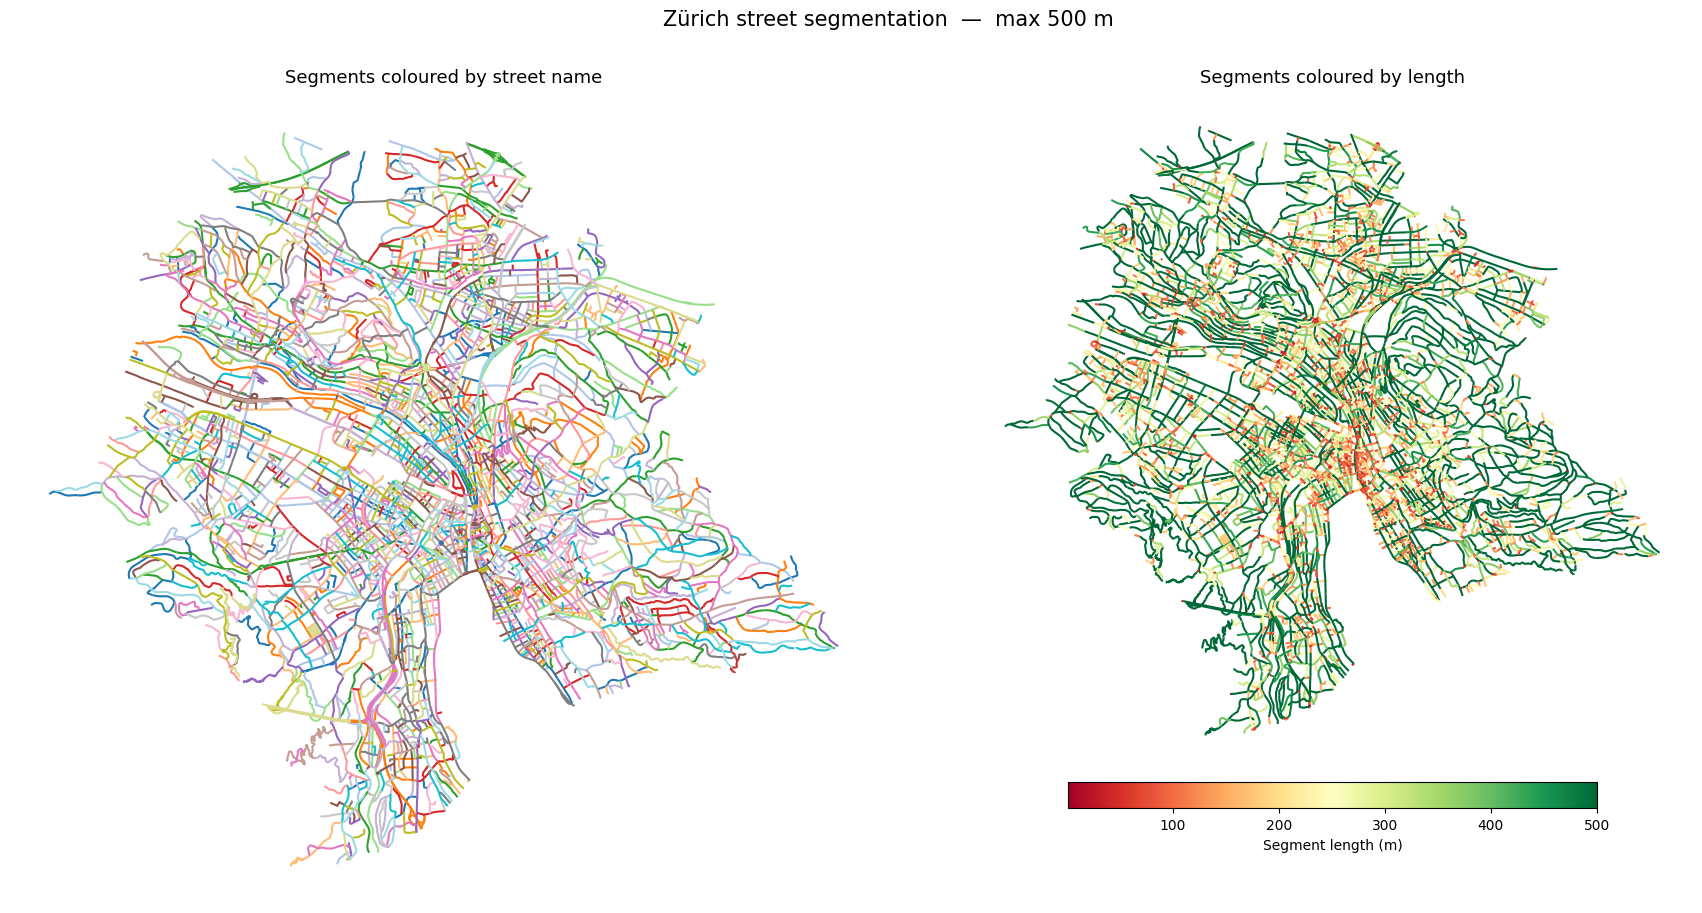

Total segments    : 5109
Full 500 m segs   : 934
Short stubs (<50m): 756
Mean length       : 222.6 m
Median length     : 165.2 m


In [ ]:
# ── 0. Install & download ─────────────────────────────────────────────────────
# shapefile has 4 files, .shp stores the geometry and coordinates, .dbf the attribute table
#.shx is an index so the file can be read quickly, and .prj stores the coordinate reference system
!pip install geopandas shapely -q

!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.shp
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.dbf
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.shx
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.prj

# ── 1. Imports ────────────────────────────────────────────────────────────────
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import LineString

# ── 2.  existing classes ──────────────────────────────────────────────────

class Point():
    def __init__(self, x=None, y=None): #stores the coordinates on object
        self.x = x
        self.y = y
    def __repr__(self): #string representation of point
        return f'Point(x={self.x}, y={self.y})'
    def __eq__(self, other): #equality check
        if not isinstance(other, Point): return False
        return self.x == other.x and self.y == other.y
    def isEqual(self, other):
        return self.__eq__(other)
    def __hash__(self): #makes Points usable in sets and dicts, helps filter duplicates because the same coordinates, same hash
        return hash((self.x, self.y))
    def distanceTo(self, other): #eculidean distance, pythagoras
        return ((self.x - other.x)**2 + (self.y - other.y)**2) ** 0.5
    def toTuple(self): #convversion back to tuple
        return (self.x, self.y)

class Segment():
    def __init__(self, p0, p1, sid=None):#stores to point objects as start and end of segment
        self.start = p0
        self.end   = p1
        self.sid   = sid
    def __repr__(self):
        return f'Segment with start {self.start} and end {self.end}.' #representation segment
    def isIdentical(self, other): #checks if two segments conncect the same two points, direction doesn't matter
        return (self.start.isEqual(other.start) or self.start.isEqual(other.end)) and \
               (self.end.isEqual(other.end)     or self.end.isEqual(other.start))
    def length(self): #the segments length
        return self.start.distanceTo(self.end)

class Polyline():
    """ A street as an ordered list of Points."""
    def __init__(self, coords):
        # coords: list of (x, y) tuples from shapely's part.coords into points
        self.points = [Point(x, y) for x, y in coords]

    def __repr__(self): #representation, shows how many points in a polyline
        return f'Polyline with {len(self.points)} points'

    def totalLength(self):
        """Sum of all segment lengths along the polyline."""
        return sum(
            self.points[i].distanceTo(self.points[i+1])
            for i in range(len(self.points) - 1) #-1 because, example 4 points but 3 edges
        )

    def interpolatePoint(self, dist):
        """
        Return the Point lying exactly `dist` metres along the polyline.
        Walks edge-by-edge; linearly interpolates within the target edge.
        """
        walked = 0.0 #travel along the line
        for i in range(len(self.points) - 1):
            a    = self.points[i] #start
            b    = self.points[i + 1] #end
            edge = a.distanceTo(b) #length
            if walked + edge >= dist: #does target distance fall along this edge?
                t = (dist - walked) / edge      # fraction along this edge between 0 and 1, how far target point along this edge
                return Point(
                    a.x + t * (b.x - a.x), #linear interpolation, t percentage of the way from a to b
                    a.y + t * (b.y - a.y)
                )
            walked += edge #if target not on edge, add edge length to walked
        return self.points[-1]                  # dist >= total → return endpoint

    def cutSegment(self, start, end):
        """
        Return a new Polyline between distances `start` and `end`.
        Caps both ends with interpolated Points; keeps interior vertices.
        """
        pts    = [self.interpolatePoint(start)] #calls interpolate point to find the exact coordinates where the segment begins
        #first point of new subpolyline
        walked = 0.0 #goes edge by edge accumulating distance
        for i in range(len(self.points) - 1):
            a    = self.points[i]
            b    = self.points[i + 1]
            edge = a.distanceTo(b)
            mid  = walked + edge
            if mid > start and walked < end:    # edge overlaps the window
                if mid < end:
                    pts.append(b)               # does edge end before window closes? if yes, b is kept as interior vertex
            walked += edge
            if walked >= end: #if walked past end break the loop
                break
        pts.append(self.interpolatePoint(end)) #if b oustide, skip the vertex and let interpolatePoint(end) handle closing cut
        return Polyline([p.toTuple() for p in pts]) #converts all point object back to tuple and stores them as a polyline
        #polyline is the cut segment with all interior vertices preserved

    def toShapely(self):
        """Convert to a Shapely LineString for GeoDataFrame storage."""
        return LineString([p.toTuple() for p in self.points])

    def splitInto(self, max_len):
        """
        Yield (seg_id, Polyline) pairs, each at most `max_len` metres long.
        """
        total  = self.totalLength()
        start  = 0.0
        seg_id = 0
        while start < total:
            end = min(start + max_len, total)
            yield seg_id, self.cutSegment(start, end)
            start += max_len
            seg_id += 1

class PointGroup():
    def __init__(self, data=None, xcol=None, ycol=None):
        self.points = []
        self.size   = len(data)
        for d in data:
            self.points.append(Point(d[xcol], d[ycol]))
    def __repr__(self):
        return f'Polygon PointGroup containing {self.size} points'
    def isClosed(self):
        return self.points[0] == self.points[-1]
    def removeDuplicates(self):
        oldn         = len(self.points)
        self.points  = list(dict.fromkeys(self.points))
        self.points.append(self.points[0])
        self.size    = len(self.points)
        print(f'The old polygon had {oldn} points, now we only have {self.size}.')

class Bbox():
    def __init__(self, segment):
        self.min_x = min(segment.start.x, segment.end.x)
        self.max_x = max(segment.start.x, segment.end.x)
        self.min_y = min(segment.start.y, segment.end.y)
        self.max_y = max(segment.start.y, segment.end.y)
    def testOverlap(self, other):
        return not (self.max_x < other.min_x or self.min_x > other.max_x or
                    self.max_y < other.min_y or self.min_y > other.max_y)

# ── 3. Load & segment ─────────────────────────────────────────────────────────
NAME_COLUMN = 'STN_TEXT'
MAX_LEN     = 500

gdf  = gpd.read_file('Streets_filtered_Zurich.shp')
rows = []

for _, row in gdf.iterrows():
    geom  = row.geometry
    parts = list(geom.geoms) if geom.geom_type == 'MultiLineString' else [geom]

    for part in parts:
        polyline = Polyline(list(part.coords))          # ← your class

        for seg_id, seg in polyline.splitInto(MAX_LEN): # ← your class methods
            new_row              = row.copy()
            new_row.geometry     = seg.toShapely()
            new_row['seg_id']    = seg_id
            new_row['seg_len_m'] = round(seg.totalLength(), 2)
            rows.append(new_row)

result = gpd.GeoDataFrame(rows, crs=gdf.crs).reset_index(drop=True)
print(f'Input: {len(gdf)} streets → Output: {len(result)} segments')

# ── 4. Display sample ─────────────────────────────────────────────────────────
display(result[[NAME_COLUMN, 'seg_id', 'seg_len_m', 'Shape_Leng']].head(10))

# ── 5. Visualize ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

unique_names     = result[NAME_COLUMN].unique()
result['name_int'] = result[NAME_COLUMN].map({n: i for i, n in enumerate(unique_names)})

result.plot(ax=axes[0], column='name_int', linewidth=1.5, cmap='tab20', legend=False)
axes[0].set_title('Segments coloured by street name', fontsize=13, pad=10)
axes[0].set_axis_off()

result.plot(ax=axes[1], column='seg_len_m', linewidth=1.5, cmap='RdYlGn', legend=True,
    legend_kwds={'label': 'Segment length (m)', 'orientation': 'horizontal',
                 'shrink': 0.6, 'pad': 0.02})
axes[1].set_title('Segments coloured by length', fontsize=13, pad=10)
axes[1].set_axis_off()

plt.suptitle('Zürich street segmentation  —  max 500 m', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# ── 6. Quick stats ────────────────────────────────────────────────────────────
print(f"Total segments    : {len(result)}")
print(f"Full 500 m segs   : {(result['seg_len_m'] == 500).sum()}")
print(f"Short stubs (<50m): {(result['seg_len_m'] < 50).sum()}")
print(f"Mean length       : {result['seg_len_m'].mean():.1f} m")
print(f"Median length     : {result['seg_len_m'].median():.1f} m")



In [ ]:
#Buffer creation MURIEL

import math

def segment_rectangle(p0, p1, width):

    #Rectancle creation
    dx = p1.x - p0.x
    dy = p1.y - p0.y

    segment_length = Segment.length(p0,p1)
    dx

    dx /= segment_length
    dy /= segment_length

    nx = -dy
    ny = dx

    w = width / 2

    # 4 Eckpunkte des Rechtecks
    points = []

    p0_left  = Point(p0.x + nx*w, p0.y + ny*w)
    p0_right = Point(p0.x - nx*w, p0.y - ny*w)
    p1_left  = Point(p1.x + nx*w, p1.y + ny*w)
    p1_right = Point(p1.x - nx*w, p1.y - ny*w)

    #Add key points of retangle to point list
    points.append(p0_left)
    points.append(p1_left)
    points.append(p1_right)
    points.append(p0_right)

    #circle creation
    for i in range(16):
        angle = 2 * math.pi * i / 16
        x_circle = p0.x + w * math.cos(angle)
        y_circle = p0.y + w * math.sin(angle)

        if x_circle.x < p0_left.x and x_circle.x < p0_right.x:
            points.append(Point(x_circle.x, y_circle.y))

        if x_circle.x > p1_left.x and x_circle.x > p1_right.x:
            points.append(Point(x_circle.x, y_circle.y))
    return points



#create rectangle around each street segment"""


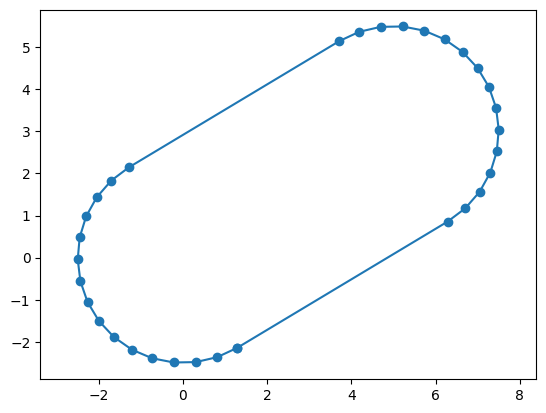

[Point(x=1.286239388568816, y=-2.1437323142813605),
 Point(x=0.812424961774999, y=-2.3643108259035843),
 Point(x=0.30310366570412084, y=-2.4815576092117473),
 Point(x=-0.21946471501078313, y=-2.490348417162794),
 Point(x=-0.7324414345711728, y=-2.390299049266288),
 Point(x=-1.2134069487968555, y=-2.1857821429894386),
 Point(x=-1.6413407567875724, y=-1.8857360685175428),
 Point(x=-1.9975400976798894, y=-1.5032742790858287),
 Point(x=-2.266437351042738, y=-1.0551121901477472),
 Point(x=-2.436280416591983, y=-0.5608366355101904),
 Point(x=-2.4996463373656725, y=-0.04204982870807866),
 Point(x=-2.453765718562571, y=0.47857475738604105),
 Point(x=-2.30064376338401, y=0.9782833301259182),
 Point(x=-2.0469726360319545, y=1.4352362270150476),
 Point(x=-1.7038389820208102, y=1.8294624137560977),
 Point(x=-1.286239388568817, y=2.1437323142813596),
 Point(x=3.7137606114311836, y=5.14373231428136),
 Point(x=4.187575038225001, y=5.364310825903584),
 Point(x=4.696896334295879, y=5.481557609211746),


In [ ]:
import math

def segment_rectangle(p0, p1, width, num_circle_points=16):

    # Direction vector
    dx = p1.x - p0.x
    dy = p1.y - p0.y

    length = Segment(p0, p1).length()
    dx /= length
    dy /= length

    # Normal vector
    nx = -dy
    ny = dx

    w = width / 2

    # Rectangle corners
    p0_left  = Point(p0.x + nx*w, p0.y + ny*w)
    p0_right = Point(p0.x - nx*w, p0.y - ny*w)
    p1_left  = Point(p1.x + nx*w, p1.y + ny*w)
    p1_right = Point(p1.x - nx*w, p1.y - ny*w)

    points = []

    # --- LEFT CAP (circle around p0) ---
    for i in range(num_circle_points):
        angle = math.pi - math.pi * i / (num_circle_points - 1)  # half circle
        x = p0.x + w * (math.cos(angle) * nx - math.sin(angle) * dx)
        y = p0.y + w * (math.cos(angle) * ny - math.sin(angle) * dy)
        points.append(Point(x, y))

    # --- RIGHT CAP (circle around p1) ---
    for i in range(num_circle_points):
        angle = - math.pi * i / (num_circle_points - 1)  # other half
        x = p1.x + w * (math.cos(angle) * nx - math.sin(angle) * dx)
        y = p1.y + w * (math.cos(angle) * ny - math.sin(angle) * dy)
        points.append(Point(x, y))

    # optional: close polygon
    points.append(points[0])

    xs = [p.x for p in points]
    ys = [p.y for p in points]

    plt.figure()
    plt.plot(xs, ys, '-o')
    plt.axis('equal')
    plt.show()

    return points



p0 = Point(0, 0)
p1 = Point(5, 3)

segment_rectangle(p0, p1, 5)

In [ ]:
import matplotlib.pyplot as plt

seg = result[result["unique_id"] == 2].iloc[0]
line = seg.geometry
x, y = line.xy


fig, ax = plt.subplots()

ax.plot(x, y, "-o")  # Linie + Punkte gleichzeitig

plt.show()

NameError: name 'segments' is not defined

In [ ]:
import csv, math
from collections import defaultdict
from geo_proxy.shp_parser import read_shp
from geo_proxy.street_segmentation import (
    segment_streets, save_segments_csv, lv95_to_wgs84
)

# ── Settings ─────────────────────────────────────────────────────────
SHP_FILE   = 'streets_ZH.shp'
CSV_FILE   = 'amtliches-strassenverzeichnis_ch_2056.csv'
OUT_FILE   = 'data/zurich_street_segments.csv'
MAX_SEG_M  = 500
# ─────────────────────────────────────────────────────────────────────

# Run the full segmentation pipeline
street_segments = segment_streets(
    shp_path=SHP_FILE,
    csv_path=CSV_FILE,
    max_segment_length=MAX_SEG_M,
)

# Save to CSV for later use
save_segments_csv(street_segments, OUT_FILE)

# ── Summary statistics ───────────────────────────────────────────────
named = [s for s in street_segments if s['street_name'] != 'Unknown']
print(f'\nNamed segments: {len(named)} / {len(street_segments)}')

street_lengths = defaultdict(float)
for s in named:
    street_lengths[s['street_name']] += s['length_m']
top5 = sorted(street_lengths.items(), key=lambda x: -x[1])[:5]
print('\nTop 5 longest named streets:')
for name, length in top5:
    print(f'  {name}: {length:.0f} m')

print(f'\nSample segments:')
for s in named[:5]:
    print(f"  {s['street_name']:30s} seg {s['segment_id']}/{s['total_segments']}  "
          f"{s['length_m']:>7.1f}m  ({s['start_lat']}, {s['start_lon']})")

ModuleNotFoundError: No module named 'geo_proxy'

# 7. Creation of Buffer

**Task owner: Guillermo**

For each street segment, we construct a **rectangular buffer polygon** at a given distance (50 m default).
This is Algorithm 1 from our pipeline, implemented in `geo_proxy/algorithms.py`.

**Method (Lectures 1, 3):**
1. Compute the direction vector of the segment AB.
2. Rotate 90° to get the perpendicular unit vector.
3. Convert the buffer distance from metres to degrees using Haversine constants at the segment's mid-latitude (Lecture 1).
4. Offset both endpoints by ±perpendicular → four corners of a rectangle.

The resulting `Polygon` object carries a bounding box for fast spatial filtering (Lectures 3–4).

**Complexity:** O(1) per segment — constant number of geometric operations.

We also demonstrate `segments_intersect()` which uses four turn tests (cross products) with a
bounding-box pre-filter (Lecture 3) to detect overlapping buffer regions.

In [ ]:
from geo_proxy.primitives import Point, Segment, Polygon
from geo_proxy.algorithms import (
    build_segment_buffer, point_in_polygon, segments_intersect,
    SOUND_CATEGORIES
)

# ── Build Segment objects from our segmented streets ────────────────
# Use only named segments for the analysis
named_segments = [s for s in street_segments if s['street_name'] != 'Unknown']

# Create Segment primitives (lon = x, lat = y in WGS84)
seg_objects = []
seg_names   = []
for s in named_segments:
    p1 = Point(s['start_lon'], s['start_lat'])
    p2 = Point(s['end_lon'],   s['end_lat'])
    seg_objects.append(Segment(p1, p2))
    seg_names.append(s['street_name'])

print(f'Created {len(seg_objects)} Segment objects')

# ── Build buffer polygons (Algorithm 1) ───────────────────────────
BUFFER_DISTANCE = 50.0  # metres

buffers = []
for seg in seg_objects:
    buf = build_segment_buffer(seg, distance_m=BUFFER_DISTANCE)
    buffers.append(buf)

print(f'Built {len(buffers)} buffer polygons ({BUFFER_DISTANCE}m distance)')

# ── Demonstrate one buffer ────────────────────────────────────────
demo_idx = 0
demo_seg = seg_objects[demo_idx]
demo_buf = buffers[demo_idx]
print(f'\nDemo: {seg_names[demo_idx]}')
print(f'  Segment: ({demo_seg.p1.x:.6f}, {demo_seg.p1.y:.6f}) -> '
      f'({demo_seg.p2.x:.6f}, {demo_seg.p2.y:.6f})')
print(f'  Length: {demo_seg.length():.1f} m')
print(f'  Buffer vertices:')
for i, v in enumerate(demo_buf.vertices):
    print(f'    V{i}: ({v.x:.6f}, {v.y:.6f})')
centroid = demo_buf.calculate_centroid()
print(f'  Buffer centroid: ({centroid.x:.6f}, {centroid.y:.6f})')
print(f'  Buffer area: {demo_buf.calculate_area():.10f} sq degrees')

# ── Demonstrate segment intersection (Lecture 3 – turn test) ──────
if len(seg_objects) >= 2:
    cross = segments_intersect(seg_objects[0], seg_objects[1])
    print(f'\nSegments 0 and 1 intersect: {cross}')

Created 5559 Segment objects
Built 5559 buffer polygons (50.0m distance)

Demo: Häringstrasse
  Segment: (8.544509, 47.376738) -> (8.547257, 47.373004)
  Length: 463.8 m
  Buffer vertices:
    V0: (8.545043, 47.377004)
    V1: (8.547791, 47.373271)
    V2: (8.546723, 47.372738)
    V3: (8.543974, 47.376471)
  Buffer centroid: (8.545883, 47.374871)
  Buffer area: 0.0000054517 sq degrees

Segments 0 and 1 intersect: False


# 8. Point-in-Polygon: Spatial Join & Sound Profile Computation

**Algorithm 2 (Lecture 4):** Ray-casting point-in-polygon with even-odd rule (Jordan Curve Theorem).
1. Bounding-box pre-filter (O(1)) rejects most non-candidate points.
2. Cast a horizontal ray from the test point to +∞.
3. Count intersections with polygon edges.
4. Odd count → point is inside.

**Algorithm 3:** Sound profile computation with z-score normalisation (Aiello et al., 2016).
- `sound(j,c) = tags(j,c) / tags(j)` — fraction per category per segment.
- `z(j,c) = (sound(j,c) - μ_c) / σ_c` — z-score normalisation for cross-category comparison.
- Dominant sound = category with highest z-score.

In [ ]:
from geo_proxy.pipeline import assign_sound_category, spatial_join, CATEGORY_WORD_SETS
from geo_proxy.algorithms import compute_sound_profile, zscore_normalise, dominant_sound
from geo_proxy.validation import parse_csv_points, parse_csv_noise, run_validation
from collections import Counter

# ── Load sound observation data ──────────────────────────────────
sound_points = parse_csv_points('data/zurich_sounds.csv')
print(f'Loaded {len(sound_points)} sound observation points')

# Show category distribution
cat_dist = Counter(p['sound_category'] for p in sound_points)
print('Category distribution:')
for cat, cnt in sorted(cat_dist.items(), key=lambda x: -x[1]):
    print(f'  {cat:12s}: {cnt:3d}')

# ── Run full spatial join pipeline (Algorithms 1+2+3) ────────────
print('\nRunning spatial join pipeline ...')
results = spatial_join(seg_objects, sound_points, buffer_distance=BUFFER_DISTANCE)
print(f'Processed {len(results)} street segments')

# ── Results summary ──────────────────────────────────────────────
sound_dist = Counter(r['dominant_sound'] for r in results)
print(f'\nDominant sound distribution:')
for cat, count in sorted(sound_dist.items(), key=lambda x: -x[1]):
    pct = count / len(results) * 100
    print(f'  {cat:12s}: {count:4d} segments ({pct:.1f}%)')

matched = [r for r in results if r['matched_points'] > 0]
print(f'\nSegments with >= 1 matched point: {len(matched)} / {len(results)}')
if matched:
    avg = sum(r['matched_points'] for r in matched) / len(matched)
    print(f'Average matched points per segment: {avg:.1f}')

# ── Validation against noise data ────────────────────────────────
noise_data = parse_csv_noise('data/zurich_noise.csv')
print(f'\nLoaded {len(noise_data)} noise measurement points')

val = run_validation(results, noise_data)
print(f'Spearman rank correlation (transport z-score vs dB):')
print(f'  rho = {val["spearman_rho"]:.4f}')
print(f'  n   = {val["n_matched_segments"]} matched segments')
print(f'  {val["interpretation"]}')

Loaded 800 sound observation points
Category distribution:
  transport   : 185
  nature      : 179
  human       : 167
  music       : 107
  indoor      :  98
  mechanical  :  64

Running spatial join pipeline ...
Processed 5559 street segments

Dominant sound distribution:
  none        : 5225 segments (94.0%)
  nature      :   69 segments (1.2%)
  human       :   64 segments (1.2%)
  music       :   53 segments (1.0%)
  indoor      :   53 segments (1.0%)
  mechanical  :   48 segments (0.9%)
  transport   :   47 segments (0.8%)

Segments with >= 1 matched point: 334 / 5559
Average matched points per segment: 5.4

Loaded 150 noise measurement points
Spearman rank correlation (transport z-score vs dB):
  rho = 0.1444
  n   = 496 matched segments
  Positive correlation supports the Chatty Maps hypothesis.


9. Visualization

In [ ]:
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for Colab compatibility
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLOURS = {
    'transport':  '#e74c3c',
    'nature':     '#2ecc71',
    'human':      '#3498db',
    'music':      '#9b59b6',
    'mechanical': '#e67e22',
    'indoor':     '#95a5a6',
    'none':       '#ecf0f1',
}

# ── Plot 1: Sound map ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
for r in results:
    seg = r['segment']
    colour = COLOURS.get(r['dominant_sound'], '#cccccc')
    lw = 2.5 if r['matched_points'] > 0 else 0.4
    alpha = 0.9 if r['matched_points'] > 0 else 0.2
    ax.plot([seg.p1.x, seg.p2.x], [seg.p1.y, seg.p2.y],
            color=colour, linewidth=lw, alpha=alpha)

patches = [mpatches.Patch(color=c, label=cat)
           for cat, c in COLOURS.items() if cat != 'none']
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Chatty Maps Zürich – Dominant Sound per Street Segment')
plt.tight_layout()
plt.savefig('output_soundmap.png', dpi=150)
plt.show()
print('Sound map saved to output_soundmap.png')

# ── Plot 2: Buffer example ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
example = next((r for r in results if r['matched_points'] >= 2), results[0])
seg = example['segment']
buf = example['buffer']

verts = [(v.x, v.y) for v in buf.vertices] + [(buf.vertices[0].x, buf.vertices[0].y)]
xs, ys = zip(*verts)
ax.fill(xs, ys, alpha=0.2, color='blue', label=f'{BUFFER_DISTANCE}m buffer')
ax.plot(xs, ys, 'b--', linewidth=1)
ax.plot([seg.p1.x, seg.p2.x], [seg.p1.y, seg.p2.y],
        'b-', linewidth=3, label='Street segment')

for p in sound_points:
    if point_in_polygon(p['geometry'], buf):
        c = COLOURS.get(p['sound_category'], 'gray')
        ax.plot(p['geometry'].x, p['geometry'].y, 'o', color=c, markersize=8)

c = example['centroid']
ax.plot(c.x, c.y, 'kx', markersize=12, markeredgewidth=2, label='Centroid')
ax.legend(fontsize=8)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f"Buffer Example — Dominant: {example['dominant_sound']} "
             f"({example['matched_points']} points)")
plt.tight_layout()
plt.savefig('output_buffer_example.png', dpi=150)
plt.show()
print('Buffer example saved to output_buffer_example.png')

C:\Users\gfilg\AppData\Local\Temp\ipykernel_2072\1930368377.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Sound map saved to output_soundmap.png
Buffer example saved to output_buffer_example.png


C:\Users\gfilg\AppData\Local\Temp\ipykernel_2072\1930368377.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
